<a href="https://colab.research.google.com/github/ShashankSatishkumar/Lasers/blob/main/maxbrilgainfordiffpumpfwhm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

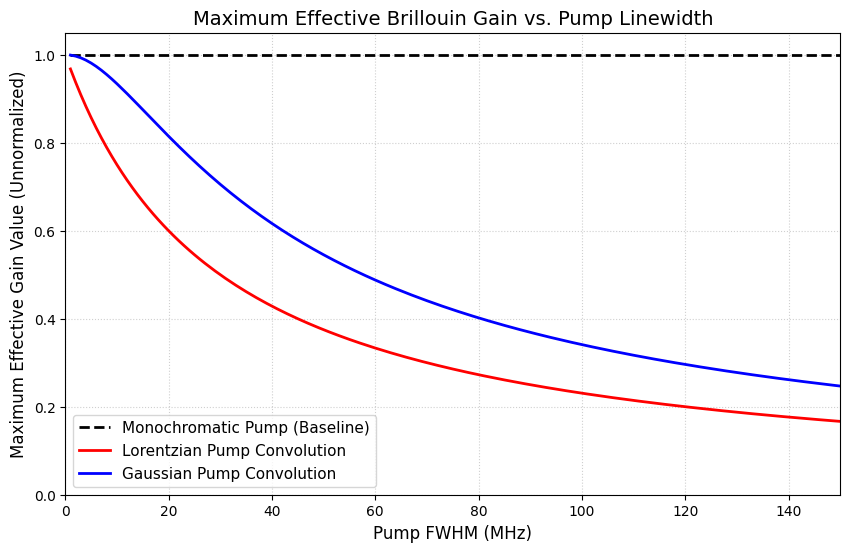

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
gamma_B=30.0
pump_w=np.linspace(1,150,150)
dif=np.linspace(-1500,1500,10000)
dnu=dif[1]-dif[0]
gain_mono = (gamma_B / 2)**2 / ((gamma_B / 2)**2 + dif**2)
mx_mono=np.max(gain_mono)
mono_peak=[]
lor_peak=[]
gaus_peak=[]
for i in pump_w:
  lor_p = (1 / np.pi) * (i / 2) / ((i / 2)**2 + dif**2)
  sigma_p = i/ (2 * np.sqrt(2 * np.log(2)))
  gaus_p = (1 / (sigma_p * np.sqrt(2 * np.pi))) * np.exp(-dif**2 / (2 * sigma_p**2))
  gain_lor = np.convolve(gain_mono, lor_p, mode='same') * dnu
  gain_gaus = np.convolve(gain_mono, gaus_p, mode='same') * dnu
  mono_peak.append(mx_mono)
  lor_peak.append(np.max(gain_lor))
  gaus_peak.append(np.max(gain_gaus))
plt.figure(figsize=(10, 6))
plt.plot(pump_w, mono_peak, 'k--', label='Monochromatic Pump (Baseline)', linewidth=2)
plt.plot(pump_w, lor_peak, 'r-', label='Lorentzian Pump Convolution', linewidth=2)
plt.plot(pump_w,gaus_peak, 'b-', label='Gaussian Pump Convolution', linewidth=2)

plt.title('Maximum Effective Brillouin Gain vs. Pump Linewidth', fontsize=14)
plt.xlabel('Pump FWHM (MHz)', fontsize=12)
plt.ylabel('Maximum Effective Gain Value (Unnormalized)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim([0, 150])
plt.ylim([0, 1.05])

plt.show()